In [ ]:
# Install required GPU packages if running in Google Colab
import sys
if 'google.colab' in sys.modules:
    print("Google Colab environment detected. Installing required packages...")
    %pip install -q -U transformers bitsandbytes accelerate datasets scipy huggingface_hub
    sys.path.insert(0, '/content')

import os
import json
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import huggingface_hub

os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from tqdm.auto import tqdm

# Import project building blocks from local .py modules
from dataset import load_uklex18_dataset, load_eurlex21_dataset, get_head_tail_indices, get_data_collator
from models import LegalBertClassifier, LegalBertLWAN
from losses import SpectralDecouplingLoss
from metrics import evaluate_predictions_by_year, compute_temporal_f1_metrics, evaluate_model, evaluate_by_year
from utils import train_model, save_experiment_results, plot_temporal_drift, analyze_model_errors
from llm_decoder import LlamaPromptBuilder, parse_llm_json_output, evaluate_llama3_zero_shot, evaluate_llama3_few_shot, extract_sample_meta



In [ ]:
# Uncomment and run if setting up in a new environment
# %pip install -r requirements.txt

# 📊 Phase 0: Exploratory Data Analysis & Chronological Splits
Overview of **UK-LEX-18** and **EUR-LEX-21** chronological dataset splits and Head/Tail class partitioning following Chalkidis & Søgaard (2022).

| Dataset | Total Docs | Training Partition | Validation Partition | Test Partition | Multi-Label Targets |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **UK-LEX-18** | 36,500 | 1975–2002 (21,391 docs) | 2003–2007 (6,128 docs) | 2008–2018 (8,981 docs) | 18 Top-Level Subjects |
| **EUR-LEX-21** | 65,000 | 1958–2010 (55,000 docs) | 2010–2012 (5,000 docs) | 2012–2016 (5,000 docs) | 21 EuroVoc Level 1 |


In [2]:
# Authenticate with HuggingFace Hub
load_dotenv()
hf_token = os.getenv("HF_TOKEN")
if hf_token:
    huggingface_hub.login(token=hf_token)
    print("Login status: Authenticated securely with HuggingFace Hub")
else:
    print("Security Note: No HF_TOKEN found in .env file. Proceeding with public datasets.")


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Login status: Authenticated securely with HuggingFace Hub


In [2]:
# Inspect dataset statistics using local dataset.py module
uk_ds, uk_map, uk_head, uk_tail = load_uklex18_dataset()
eur_ds, eur_head, eur_tail = load_eurlex21_dataset()

print("==================================================")
print(f"UK-LEX-18  | Head Classes: {len(uk_head)} | Tail Classes: {len(uk_tail)}")
print(f"EUR-LEX-21 | Head Classes: {len(eur_head)} | Tail Classes: {len(eur_tail)}")
print("==================================================")


Map:   0%|          | 0/21391 [00:00<?, ? examples/s]

Map:   0%|          | 0/6128 [00:00<?, ? examples/s]

Map:   0%|          | 0/8981 [00:00<?, ? examples/s]

UK-LEX-18  | Head Classes: 9 | Tail Classes: 9
EUR-LEX-21 | Head Classes: 10 | Tail Classes: 11


# Phase 1: Data Engineering and Chronological Splitting

In [3]:
import importlib
import dataset
importlib.reload(dataset)

encoded_ds, eur_head_indices, eur_tail_indices = dataset.load_eurlex21_dataset()

# Print columns to verify 'year' is present:
print("EUR-LEX Test Columns:", encoded_ds['test'].column_names)

# Hardware configuration
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Load UK-LEX-18 Chronological Pipeline (Dataset + Tokenization + Head/Tail Splits)
uklex_tokenized, uk_label_to_idx, uk_head_indices, uk_tail_indices = load_uklex18_dataset()
NUM_UK_LABELS = len(uk_label_to_idx)
print(f"UK-LEX-18 Loaded: Train={len(uklex_tokenized['train']):,}, Val={len(uklex_tokenized['validation']):,}, Test={len(uklex_tokenized['test']):,}")
print(f"  • Head Classes: {len(uk_head_indices)} | Tail Classes: {len(uk_tail_indices)} | Total Labels: {NUM_UK_LABELS}")

# Load EUR-LEX-21 Chronological Pipeline (Dataset + Tokenization + Head/Tail Splits)
encoded_ds, eur_head_indices, eur_tail_indices = load_eurlex21_dataset()
NUM_CLASSES = 21
MODEL_NAME = 'nlpaueb/legal-bert-base-uncased'
print(f"EUR-LEX-21 Loaded: Train={len(encoded_ds['train']):,}, Val={len(encoded_ds['validation']):,}, Test={len(encoded_ds['test']):,}")
print(f"  • Head Classes: {len(eur_head_indices)} | Tail Classes: {len(eur_tail_indices)} | Total Labels: {NUM_CLASSES}")

# Dynamic padding data collator
data_collator = get_data_collator()


EUR-LEX Test Columns: ['celex_id', 'labels', 'input_ids', 'token_type_ids', 'attention_mask', 'year']
Using device: mps


Map:   0%|          | 0/21391 [00:00<?, ? examples/s]

Map:   0%|          | 0/6128 [00:00<?, ? examples/s]

Map:   0%|          | 0/8981 [00:00<?, ? examples/s]

UK-LEX-18 Loaded: Train=21,391, Val=6,128, Test=8,981
  • Head Classes: 9 | Tail Classes: 9 | Total Labels: 18
EUR-LEX-21 Loaded: Train=55,000, Val=5,000, Test=5,000
  • Head Classes: 10 | Tail Classes: 11 | Total Labels: 21


# Phase 2: Local Encoder Baseline Implementation (LEGAL-BERT and BERT-LWAN)

Establish they experimental baselines on historical training splits and measure the performance degradation when evaluating on chronologically drifted test splits with Binary Cross-Entropy (BCE) Loss, followed by evaluating Micro-F1, Macro-F1, Head-F1, and Tail-F1 metrics across shifted test sets.

In [4]:
# Hardware configuration
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon Metal Performance Shaders (MPS) backend.")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using NVIDIA CUDA GPU backend.")
else:
    device = torch.device("cpu")
    print("Using CPU backend.")

Using Apple Silicon Metal Performance Shaders (MPS) backend.


### Phase 2A: LEGAL-BERT

In [42]:
# Create DataLoaders with dynamic padding collator
train_loader = DataLoader(uklex_tokenized['train'], batch_size=8, shuffle=True, collate_fn=data_collator)
val_loader   = DataLoader(uklex_tokenized['validation'], batch_size=8, shuffle=False, collate_fn=data_collator)
test_loader  = DataLoader(uklex_tokenized['test'], batch_size=8, shuffle=False, collate_fn=data_collator)

# Initialize
model = LegalBertClassifier(num_labels=NUM_UK_LABELS)

# Check if pre-trained checkpoint already exists
if os.path.exists("checkpoints/best_legal_bert_uk18.pt"):
    print(" Found existing trained model 'checkpoints/best_legal_bert_uk18.pt'. Loading weights...")
    model.load_state_dict(torch.load("checkpoints/best_legal_bert_uk18.pt",map_location=device))
    checkpoint_file = "checkpoints/best_legal_bert_uk18.pt"
else:
    # Train model if checkpoint does not exist
    checkpoint_file = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        head_indices=uk_head_indices,
        tail_indices=uk_tail_indices,
        device=device,
        epochs=4,
        lr=3e-5,
        checkpoint_path="checkpoints/best_legal_bert_uk18.pt",
        accumulation_steps=4
        )

# Evaluate best checkpoint on test set
model.load_state_dict(torch.load(checkpoint_file, map_location=device))
test_metrics = evaluate_model(model, test_loader, device, uk_head_indices, uk_tail_indices)

print("\n" + "="*60)
print("UK-LEX CHRONOLOGICAL TEST SET RESULTS - LEGAL-BERT")
print("="*60)
for k, v in test_metrics.items():
    print(f"  • {k:<15}: {v:.4f}")
print("="*60)

# Save results for thesis tables
save_experiment_results(test_metrics, "results/results_legal_bert_uk18.json")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 Found existing trained model 'best_legal_bert_uk18.pt'. Loading weights...


Evaluating:   0%|          | 0/1123 [00:00<?, ?it/s]


UK-LEX CHRONOLOGICAL TEST SET RESULTS - LEGAL-BERT
  • Micro-F1       : 0.8165
  • Macro-F1       : 0.7736
  • Head-Micro-F1  : 0.8489
  • Head-Macro-F1  : 0.8397
  • Tail-Micro-F1  : 0.7207
  • Tail-Macro-F1  : 0.7074
 Saved experiment results to results_legal_bert_uk18.json


Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

  Evaluated Year 2008: 1200 documents


Evaluating:   0%|          | 0/37 [00:00<?, ?it/s]

  Evaluated Year 2009: 1163 documents


Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]

...

  Evaluated Year 2016: 538 documents


Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]

  Evaluated Year 2017: 608 documents


Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]

  Evaluated Year 2018: 70 documents


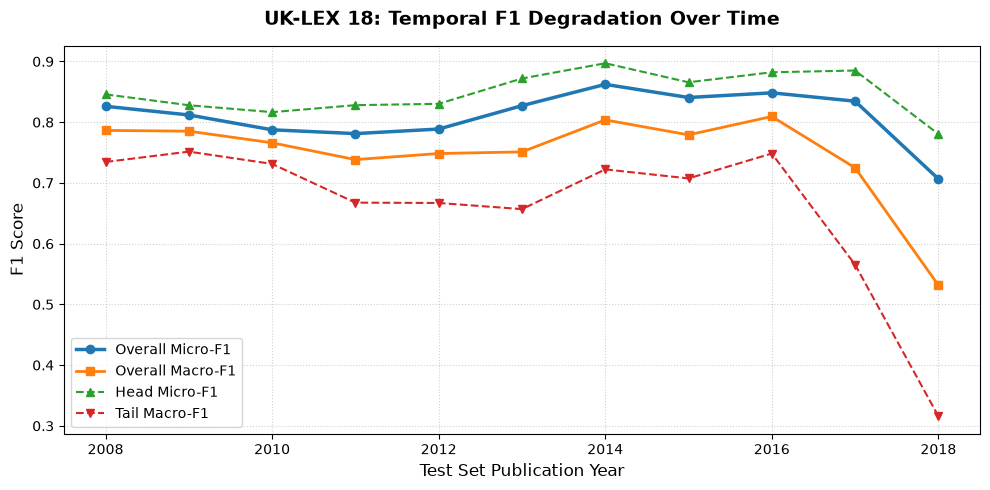

 Saved temporal drift plot to temporal_drift_line_chart.png


In [8]:
# Year-by-year temporal drift evaluation & plotting
uk_test_tokenized = uklex_tokenized['test']
uk_year_results = evaluate_by_year(model, uk_test_tokenized, device, uk_head_indices, uk_tail_indices, data_collator)
plot_temporal_drift(uk_year_results, title="UK-LEX 18: Temporal F1 Degradation Over Time")

In [9]:
save_experiment_results(uk_year_results, "results/results_uk18_year_by_year.json")

 Saved experiment results to results_uk18_year_by_year.json


In [13]:
# Qualitative Error Analysis and Failure Extraction for UK-LEX
sorted_uk_labels = list(uk_label_to_idx.keys())

uk_error_results = analyze_model_errors(
    model=model,
    dataloader=test_loader,
    raw_dataset=uklex_tokenized['test'],
    device=device,
    label_names=sorted_uk_labels,
    top_n=5
)


 QUALITATIVE ERROR ANALYSIS (Top 5 Disagreements)
• ID: doc_3393 | Year: 2011 | Title: N/A...
  True Labels: ['CHILDREN', 'CRIMINAL LAW', 'ENVIRONMENT', 'HEALTH CARE', 'LOCAL GOVERNMENT', 'PLANNING & DEVELOPMENT', 'PUBLIC ORDER', 'SOCIAL SECURITY', 'TRANSPORTATION']
  Predicted:   ['PUBLIC ORDER']

• ID: doc_4644 | Year: 2012 | Title: N/A...
  True Labels: ['CHILDREN', 'HEALTH CARE', 'TAXATION', 'TRANSPORTATION']
  Predicted:   ['LOCAL GOVERNMENT']

• ID: doc_1261 | Year: 2009 | Title: N/A...
  True Labels: ['ENVIRONMENT', 'HEALTH CARE', 'PLANNING & DEVELOPMENT', 'PUBLIC ORDER', 'TRANSPORTATION']
  Predicted:   ['PLANNING & DEVELOPMENT']

• ID: doc_1482 | Year: 2009 | Title: N/A...
  True Labels: ['AGRICULTURE & FOOD', 'TAXATION', 'TRANSPORTATION']
  Predicted:   ['ENVIRONMENT']

• ID: doc_2402 | Year: 2010 | Title: N/A...
  True Labels: ['CRIMINAL LAW', 'EU', 'IMMIGRATION & CITIZENSHIP']
  Predicted:   ['FINANCE']



In [14]:
save_experiment_results(uk_error_results, "results/results_uk18_error_analysis.json")

 Saved experiment results to results_uk18_error_analysis.json


In [30]:
# EUR-LEX DataLoaders with dynamic padding collator
eur_train_loader = DataLoader(encoded_ds['train'], batch_size=4, shuffle=True, collate_fn=data_collator)
eur_val_loader   = DataLoader(encoded_ds['validation'], batch_size=4, shuffle=False, collate_fn=data_collator)
eur_test_loader  = DataLoader(encoded_ds['test'], batch_size=4, shuffle=False, collate_fn=data_collator)

# Initialize Legal-BERT for 21 EuroVoc classes
eur_model = LegalBertClassifier(model_name=MODEL_NAME, num_labels=NUM_CLASSES)

checkpoint_file = "checkpoints/best_legal_bert_eurlex21.pt" 
if os.path.exists(checkpoint_file):
    print(f" Found existing trained model '{checkpoint_file}'. Loading weights...") 
    eur_model.load_state_dict(torch.load(checkpoint_file, map_location=device))
else:
    # Train on EUR-LEX if checkpoint does not exist
    eur_checkpoint_file = train_model(
        model=eur_model,
        train_loader=eur_train_loader,
        val_loader=eur_val_loader,
        head_indices=eur_head_indices,
        tail_indices=eur_tail_indices,
        device=device,
        epochs=2,
        lr=2e-5,
        checkpoint_path=checkpoint_file,
        accumulation_steps=8
    )

# Evaluate best checkpoint on test set (2012-2016 Chronological Split)
eur_model.load_state_dict(torch.load(checkpoint_file,map_location=device))
eur_test_metrics = evaluate_model(eur_model, eur_test_loader, device, eur_head_indices, eur_tail_indices)

print("" + "="*60)
print("EUR-LEX CHRONOLOGICAL TEST SET RESULTS - LEGAL-BERT")
print("="*60)
for k, v in eur_test_metrics.items():
    print(f"  • {k:<15}: {v:.4f}")
print("="*60)

# Save results for thesis tables
save_experiment_results(eur_test_metrics, "results/results_legal_bert_eurlex21.json")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 Found existing trained model 'best_legal_bert_eurlex21.pt'. Loading weights...


Evaluating:   0%|          | 0/1250 [00:00<?, ?it/s]

EUR-LEX CHRONOLOGICAL TEST SET RESULTS - LEGAL-BERT
  • Micro-F1       : 0.7925
  • Macro-F1       : 0.6703
  • Head-Micro-F1  : 0.8356
  • Head-Macro-F1  : 0.8059
  • Tail-Micro-F1  : 0.6363
  • Tail-Macro-F1  : 0.5469
 Saved experiment results to results_legal_bert_eurlex21.json


 'year' column not found in memory. Reloading EUR-LEX dataset...


Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

  Evaluated Year 2012: 388 documents


Evaluating:   0%|          | 0/55 [00:00<?, ?it/s]

  Evaluated Year 2013: 1742 documents


...

  Evaluated Year 2014: 2264 documents


Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]

  Evaluated Year 2015: 605 documents


Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

  Evaluated Year 2016: 1 documents


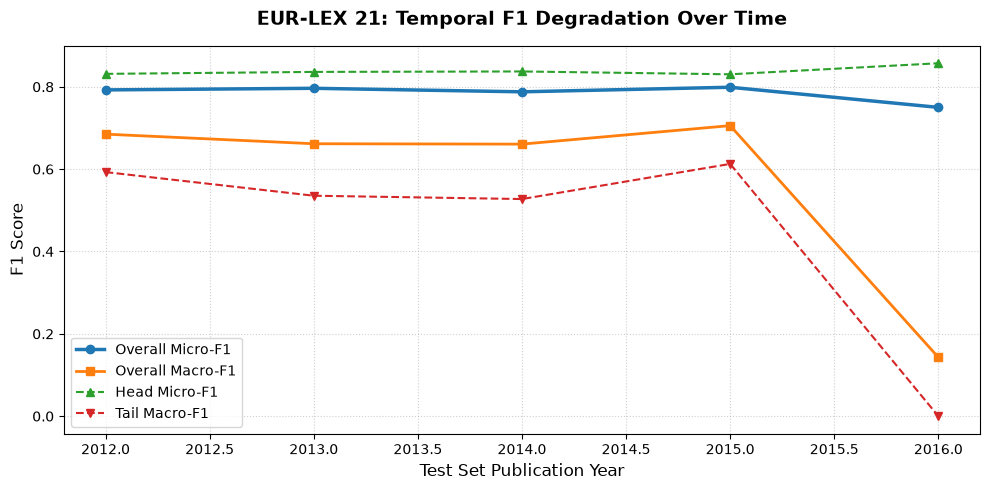

 Saved temporal drift plot to eurlex21_temporal_drift.png
 Saved experiment results to results_eur21_year_by_year.json


In [36]:
# Year-by-year temporal drift evaluation & plotting for EUR-LEX
if 'year' not in encoded_ds['test'].column_names:
    print(" 'year' column not found in memory. Reloading EUR-LEX dataset...")
    import importlib, dataset
    importlib.reload(dataset)
    encoded_ds, eur_head_indices, eur_tail_indices = dataset.load_eurlex21_dataset()

eur_year_results = evaluate_by_year(eur_model, encoded_ds['test'], device,
eur_head_indices, eur_tail_indices, data_collator)
plot_temporal_drift(eur_year_results, title="EUR-LEX 21: Temporal F1 Degradation Over Time", save_path="plots/eurlex21_temporal_drift.png")
save_experiment_results(eur_year_results, "results/results_eur21_year_by_year.json")

In [37]:
# Qualitative Error Analysis and Failure Extraction for EUR-LEX

eur_label_names = [f"EuroVoc Class {i}" for i in range(NUM_CLASSES)]

eur_error_results = analyze_model_errors(
    model=eur_model,
    dataloader=eur_test_loader,
    raw_dataset=encoded_ds['test'],
    device=device,
    label_names=eur_label_names,
    top_n=5
)


 QUALITATIVE ERROR ANALYSIS (Top 5 Disagreements)
• ID: doc_2540 | Year: 2014 | Title: N/A...
  True Labels: ['EuroVoc Class 0', 'EuroVoc Class 12', 'EuroVoc Class 15', 'EuroVoc Class 16', 'EuroVoc Class 18', 'EuroVoc Class 19']
  Predicted:   ['EuroVoc Class 2', 'EuroVoc Class 5', 'EuroVoc Class 10', 'EuroVoc Class 11', 'EuroVoc Class 15', 'EuroVoc Class 18']

• ID: doc_1414 | Year: 2014 | Title: N/A...
  True Labels: ['EuroVoc Class 0', 'EuroVoc Class 7', 'EuroVoc Class 9', 'EuroVoc Class 10', 'EuroVoc Class 13', 'EuroVoc Class 14', 'EuroVoc Class 16', 'EuroVoc Class 20']
  Predicted:   ['EuroVoc Class 14']

• ID: doc_1800 | Year: 2015 | Title: N/A...
  True Labels: ['EuroVoc Class 2', 'EuroVoc Class 8', 'EuroVoc Class 10', 'EuroVoc Class 12', 'EuroVoc Class 19']
  Predicted:   ['EuroVoc Class 2', 'EuroVoc Class 3', 'EuroVoc Class 10', 'EuroVoc Class 11', 'EuroVoc Class 15', 'EuroVoc Class 18']

• ID: doc_2905 | Year: 2014 | Title: N/A...
  True Labels: ['EuroVoc Class 0', 'EuroVoc 

In [38]:
save_experiment_results(eur_error_results, "results/results_eurlex21_error_analysis.json")

 Saved experiment results to results_eurlex21_error_analysis.json


### Phase 2B: Specialized LEGAL BERT-LWAN

Implementation and evaluation of `LegalBertLWAN` following Chalkidis & Søgaard (2022).
Uses per-label attention query vectors to extract category-specific document representations.

### UK-LEX-18

In [ ]:
import importlib
import models
importlib.reload(models)

from models import LegalBertLWAN

lwan_bce_model = LegalBertLWAN(
    model_name="nlpaueb/legal-bert-base-uncased",
    num_labels=len(uk_label_to_idx),
    attention_dim=200,
    dropout=0.1
)

# Train BERT-LWAN with standard BCE loss (ERM Baseline)
print("--- Training BERT-LWAN Baseline (BCE Loss) on UK-LEX 18 ---")
train_model(
    model=lwan_bce_model,
    train_loader=train_loader,
    val_loader=val_loader,
    head_indices=uk_head_indices,
    tail_indices=uk_tail_indices,
    device=device,
    epochs=3,
    lr=3e-5,
    checkpoint_path="checkpoints/best_lwan_uk18_bce.pt"
)

# Load best checkpoint & evaluate test metrics
lwan_bce_model.load_state_dict(torch.load("checkpoints/best_lwan_uk18_bce.pt"))
uk_lwan_bce_metrics = evaluate_model(lwan_bce_model, test_loader, device,
uk_head_indices, uk_tail_indices)
save_experiment_results(uk_lwan_bce_metrics, "results/results_lwan_bce_uk18.json")
print("\n[BERT-LWAN BCE Test Metrics]:", uk_lwan_bce_metrics)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


--- Training BERT-LWAN Baseline (BCE Loss) on UK-LEX 18 ---
Active Device: mps

[02:25:29] Epoch 1/3 | Begin
  [02:26:28] Epoch 1/3 | Batch 50/2674 | Loss: 0.2797
  [02:27:25] Epoch 1/3 | Batch 100/2674 | Loss: 0.2292
  [02:28:22] Epoch 1/3 | Batch 150/2674 | Loss: 0.1964
  [02:29:26] Epoch 1/3 | Batch 200/2674 | Loss: 0.1488
  [02:30:35] Epoch 1/3 | Batch 250/2674 | Loss: 0.1191
  [02:31:44] Epoch 1/3 | Batch 300/2674 | Loss: 0.1772
  [02:32:55] Epoch 1/3 | Batch 350/2674 | Loss: 0.0909
  [02:34:04] Epoch 1/3 | Batch 400/2674 | Loss: 0.1613
  [02:35:12] Epoch 1/3 | Batch 450/2674 | Loss: 0.1368
  [02:36:22] Saved mid-epoch checkpoint at Batch 500/2674
  [02:36:22] Epoch 1/3 | Batch 500/2674 | Loss: 0.1100
  [02:37:31] Epoch 1/3 | Batch 550/2674 | Loss: 0.0548
  [02:38:39] Epoch 1/3 | Batch 600/2674 | Loss: 0.0529
  [02:39:48] Epoch 1/3 | Batch 650/2674 | Loss: 0.1228
  [02:41:00] Epoch 1/3 | Batch 700/2674 | Loss: 0.0361
  [02:42:14] Epoch 1/3 | Batch 750/2674 | Loss: 0.0967
  [02:43:

Evaluating:   0%|          | 0/766 [00:00<?, ?it/s]

[03:33:19] --> Epoch 1/3 | Train Loss: 0.0875 | Val Micro-F1: 0.8293 | Val Tail-F1: 0.7794
[03:33:19] Saved checkpoint to best_lwan_uk18_bce.pt (Val Micro-F1: 0.8293)

[03:33:20] Epoch 2/3 | Begin
  [03:34:30] Epoch 2/3 | Batch 50/2674 | Loss: 0.0353
  [03:35:42] Epoch 2/3 | Batch 100/2674 | Loss: 0.0521
  [03:36:55] Epoch 2/3 | Batch 150/2674 | Loss: 0.0537
  [03:38:08] Epoch 2/3 | Batch 200/2674 | Loss: 0.0593
  [03:39:24] Epoch 2/3 | Batch 250/2674 | Loss: 0.0681
  [03:40:36] Epoch 2/3 | Batch 300/2674 | Loss: 0.0390
  [03:41:54] Epoch 2/3 | Batch 350/2674 | Loss: 0.0437
  [03:43:08] Epoch 2/3 | Batch 400/2674 | Loss: 0.0311
  [03:44:16] Epoch 2/3 | Batch 450/2674 | Loss: 0.0568
  [03:45:25] Saved mid-epoch checkpoint at Batch 500/2674
  [03:45:25] Epoch 2/3 | Batch 500/2674 | Loss: 0.0830
  [03:46:35] Epoch 2/3 | Batch 550/2674 | Loss: 0.0117
  [03:47:50] Epoch 2/3 | Batch 600/2674 | Loss: 0.0298
  [03:49:02] Epoch 2/3 | Batch 650/2674 | Loss: 0.0468
  [03:50:15] Epoch 2/3 | Batch 

...

[04:42:32] --> Epoch 2/3 | Train Loss: 0.0453 | Val Micro-F1: 0.8455 | Val Tail-F1: 0.7971
[04:42:32] Saved checkpoint to best_lwan_uk18_bce.pt (Val Micro-F1: 0.8455)

[04:42:33] Epoch 3/3 | Begin
  [04:43:46] Epoch 3/3 | Batch 50/2674 | Loss: 0.0793
  [04:44:57] Epoch 3/3 | Batch 100/2674 | Loss: 0.0322
  [04:46:09] Epoch 3/3 | Batch 150/2674 | Loss: 0.0593
  [04:47:20] Epoch 3/3 | Batch 200/2674 | Loss: 0.0838
  [04:48:32] Epoch 3/3 | Batch 250/2674 | Loss: 0.0345
  [04:49:44] Epoch 3/3 | Batch 300/2674 | Loss: 0.0125
  [04:50:55] Epoch 3/3 | Batch 350/2674 | Loss: 0.0456
  [04:52:07] Epoch 3/3 | Batch 400/2674 | Loss: 0.0291
  [04:53:19] Epoch 3/3 | Batch 450/2674 | Loss: 0.0112
  [04:54:31] Saved mid-epoch checkpoint at Batch 500/2674
  [04:54:31] Epoch 3/3 | Batch 500/2674 | Loss: 0.0472
  [04:55:42] Epoch 3/3 | Batch 550/2674 | Loss: 0.0787
  [04:56:54] Epoch 3/3 | Batch 600/2674 | Loss: 0.0353
  [04:58:06] Epoch 3/3 | Batch 650/2674 | Loss: 0.0140
  [04:59:17] Epoch 3/3 | Batch 

Evaluating:   0%|          | 0/766 [00:00<?, ?it/s]

[05:53:08] --> Epoch 3/3 | Train Loss: 0.0353 | Val Micro-F1: 0.8505 | Val Tail-F1: 0.8003
[05:53:08] Saved checkpoint to best_lwan_uk18_bce.pt (Val Micro-F1: 0.8505)

Training Complete


Evaluating:   0%|          | 0/1123 [00:00<?, ?it/s]

 Saved experiment results to results_lwan_bce_uk18.json

[BERT-LWAN BCE Test Metrics]: {'Micro-F1': 0.8181473404759647, 'Macro-F1': 0.7732056644622625, 'Head-Micro-F1': 0.850210164310279, 'Head-Macro-F1': 0.8392538507537582, 'Tail-Micro-F1': 0.7247774480712166, 'Tail-Macro-F1': 0.7071574781707667}



--- Running Year-by-Year Evaluation for BERT-LWAN Baseline ---


Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

  Evaluated Year 2008: 1200 documents


Evaluating:   0%|          | 0/37 [00:00<?, ?it/s]

  Evaluated Year 2009: 1163 documents


...

  Evaluated Year 2016: 538 documents


Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]

  Evaluated Year 2017: 608 documents


Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]

  Evaluated Year 2018: 70 documents
 Saved experiment results to results_lwan_bce_uk18_year_by_year.json


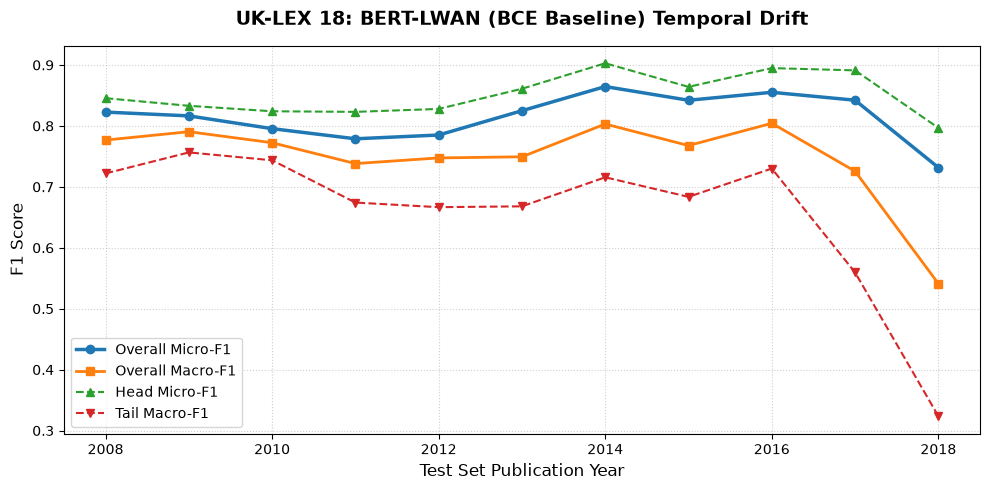

 Saved temporal drift plot to lwan_bce_uk18_drift.png


In [ ]:
# Evaluate and Save Year-by-Year Results for Temporal Drift Analysis
print("\n--- Running Year-by-Year Evaluation for BERT-LWAN Baseline ---")
lwan_bce_year_results = evaluate_by_year(
    model=lwan_bce_model,
    dataset=uklex_tokenized['test'],
    device=device,
    head_indices=uk_head_indices,
    tail_indices=uk_tail_indices,
    collate_fn=data_collator
)

# Save year-by-year metrics to JSON for your thesis tables
save_experiment_results(lwan_bce_year_results,"results/results_lwan_bce_uk18_year_by_year.json")

# Plot temporal drift graph
plot_temporal_drift(
    lwan_bce_year_results,
    title="UK-LEX 18: BERT-LWAN (BCE Baseline) Temporal Drift",
    save_path="plots/lwan_bce_uk18_drift.png"
)

### Phase 2B: Specialized LEGAL BERT-LWAN

### EUR-LEX-21

In [ ]:
# Load EUR-LEX-21 dataset and train/evaluate LegalBertLWAN with BCE loss
encoded_ds, eur_head_indices, eur_tail_indices = load_eurlex21_dataset()
data_collator = get_data_collator()
eur_train_loader = DataLoader(encoded_ds["train"], batch_size=8, shuffle=True, collate_fn=data_collator)
eur_val_loader   = DataLoader(encoded_ds["validation"], batch_size=8, shuffle=False, collate_fn=data_collator)
eur_test_loader  = DataLoader(encoded_ds["test"], batch_size=8, shuffle=False, collate_fn=data_collator)

lwan_eur21_model = LegalBertLWAN(model_name="nlpaueb/legal-bert-base-uncased", num_labels=21, attention_dim=200, dropout=0.1)
checkpoint_lwan_eur21_file = "checkpoints/best_lwan_eurlex21_bce.pt"

if os.path.exists(checkpoint_lwan_eur21_file):
    print(f" Found existing trained model '{checkpoint_lwan_eur21_file}'. Loading weights...")
    lwan_eur21_model.load_state_dict(torch.load(checkpoint_lwan_eur21_file, map_location=device))
else:
    checkpoint_lwan_eur21_file = train_model(
        model=lwan_eur21_model, train_loader=eur_train_loader, val_loader=eur_val_loader,
        head_indices=eur_head_indices, tail_indices=eur_tail_indices, device=device,
        epochs=3, lr=3e-5, checkpoint_path=checkpoint_lwan_eur21_file, accumulation_steps=4
    )

# Test set evaluation
lwan_eur21_model.load_state_dict(torch.load(checkpoint_lwan_eur21_file, map_location=device))
lwan_eur21_test_metrics = evaluate_model(lwan_eur21_model, eur_test_loader, device, eur_head_indices, eur_tail_indices)
save_experiment_results(lwan_eur21_test_metrics, "results/results_lwan_bce_eurlex21.json")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Active Device: mps

[10:03:27] Epoch 1/3 | Begin
  [10:04:23] Epoch 1/3 | Batch 50/6875 | Loss: 0.2991
  [10:05:18] Epoch 1/3 | Batch 100/6875 | Loss: 0.2762
  [10:06:20] Epoch 1/3 | Batch 150/6875 | Loss: 0.2092
  [10:07:30] Epoch 1/3 | Batch 200/6875 | Loss: 0.2699
  [10:08:41] Epoch 1/3 | Batch 250/6875 | Loss: 0.2056
  [10:09:52] Epoch 1/3 | Batch 300/6875 | Loss: 0.2400
  [10:11:00] Epoch 1/3 | Batch 350/6875 | Loss: 0.2283
  [10:12:07] Epoch 1/3 | Batch 400/6875 | Loss: 0.1642
  [10:13:14] Epoch 1/3 | Batch 450/6875 | Loss: 0.2116
  [10:14:20] Saved mid-epoch checkpoint at Batch 500/6875
  [10:14:20] Epoch 1/3 | Batch 500/6875 | Loss: 0.1301
  [10:15:24] Epoch 1/3 | Batch 550/6875 | Loss: 0.1237
  [10:16:29] Epoch 1/3 | Batch 600/6875 | Loss: 0.1583
  [10:17:33] Epoch 1/3 | Batch 650/6875 | Loss: 0.1533
  [10:18:37] Epoch 1/3 | Batch 700/6875 | Loss: 0.2049
  [10:19:40] Epoch 1/3 | Batch 750/6875 | Loss: 0.1380
  [10:20:44] Epoch 1/3 | Batch 800/6875 | Loss: 0.1560
  [10:21:46] E

Evaluating:   0%|          | 0/625 [00:00<?, ?it/s]

[12:35:45] --> Epoch 1/3 | Train Loss: 0.1485 | Val Micro-F1: 0.8174 | Val Tail-F1: 0.5816
[12:35:45] Saved checkpoint to checkpoints/best_lwan_eurlex21_bce.pt (Val Micro-F1: 0.8174)

[12:35:46] Epoch 2/3 | Begin
  [12:37:00] Epoch 2/3 | Batch 50/6875 | Loss: 0.1029
  [12:38:15] Epoch 2/3 | Batch 100/6875 | Loss: 0.1292
  [12:39:28] Epoch 2/3 | Batch 150/6875 | Loss: 0.1122
  [12:40:40] Epoch 2/3 | Batch 200/6875 | Loss: 0.1406
  [12:41:53] Epoch 2/3 | Batch 250/6875 | Loss: 0.0673
  [12:43:06] Epoch 2/3 | Batch 300/6875 | Loss: 0.1010
  [12:44:19] Epoch 2/3 | Batch 350/6875 | Loss: 0.0966
  [12:45:32] Epoch 2/3 | Batch 400/6875 | Loss: 0.1144
  [12:46:45] Epoch 2/3 | Batch 450/6875 | Loss: 0.1156
  [12:47:58] Saved mid-epoch checkpoint at Batch 500/6875
  [12:47:58] Epoch 2/3 | Batch 500/6875 | Loss: 0.0911
  [12:49:09] Epoch 2/3 | Batch 550/6875 | Loss: 0.0781
  [12:50:18] Epoch 2/3 | Batch 600/6875 | Loss: 0.1028
  [12:51:27] Epoch 2/3 | Batch 650/6875 | Loss: 0.0898
  [12:52:36] Ep

...

Evaluating:   0%|          | 0/625 [00:00<?, ?it/s]

[17:50:54] --> Epoch 3/3 | Train Loss: 0.0947 | Val Micro-F1: 0.8227 | Val Tail-F1: 0.6253

Training Complete


Evaluating:   0%|          | 0/625 [00:00<?, ?it/s]

 Saved experiment results to results/results_lwan_bce_eurlex21.json


TypeError: evaluate_by_year() missing 1 required positional argument: 'collate_fn'

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

  Evaluated Year 2012: 388 documents


Evaluating:   0%|          | 0/55 [00:00<?, ?it/s]

  Evaluated Year 2013: 1742 documents


Evaluating:   0%|          | 0/71 [00:00<?, ?it/s]

  Evaluated Year 2014: 2264 documents


Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]

  Evaluated Year 2015: 605 documents


Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

  Evaluated Year 2016: 1 documents
 Saved experiment results to results/results_lwan_bce_eurlex21_year_by_year.json


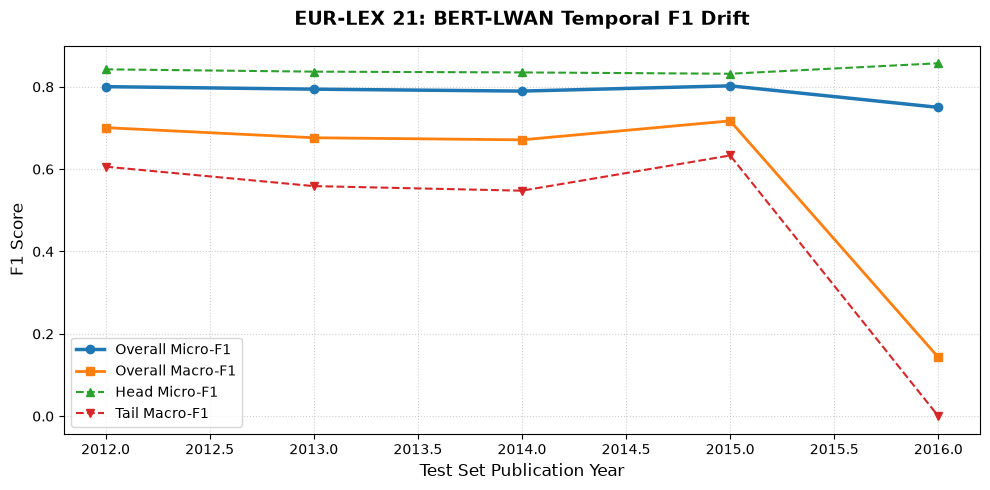

 Saved temporal drift plot to plots/lwan_bce_eurlex21_drift.png


In [6]:
# Year-by-Year Evaluation
lwan_eur21_year_results = evaluate_by_year(lwan_eur21_model, encoded_ds["test"], device, eur_head_indices, eur_tail_indices, data_collator)
save_experiment_results(lwan_eur21_year_results, "results/results_lwan_bce_eurlex21_year_by_year.json")
plot_temporal_drift(lwan_eur21_year_results, title="EUR-LEX 21: BERT-LWAN Temporal F1 Drift", save_path="plots/lwan_bce_eurlex21_drift.png")

# Phase 3: Group-Robust and Label-Wise Loss Modifications

To mitigate performance degradation under temporal concept drift specifically on sparse, long-tailed legal topics, we evaluate specialized loss functions designed to handle label imbalance and distribution shift following Chalkidis & Søgaard (2022).

Evaluated Loss Formulations:
1. Binary Cross-Entropy (BCE) Baseline
2. Spectral Decoupling Loss: Applies Spectral Decoupling Loss (λ = 0.01sd) to penalize unnormalized logit growth.
   

Map:   0%|          | 0/21391 [00:00<?, ? examples/s]

Map:   0%|          | 0/6128 [00:00<?, ? examples/s]

Map:   0%|          | 0/8981 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

  Evaluated Year 2016: 538 documents


Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]

  Evaluated Year 2017: 608 documents


Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]

  Evaluated Year 2018: 70 documents
 Saved experiment results to results/results_lwan_sd_uk18_year_by_year.json


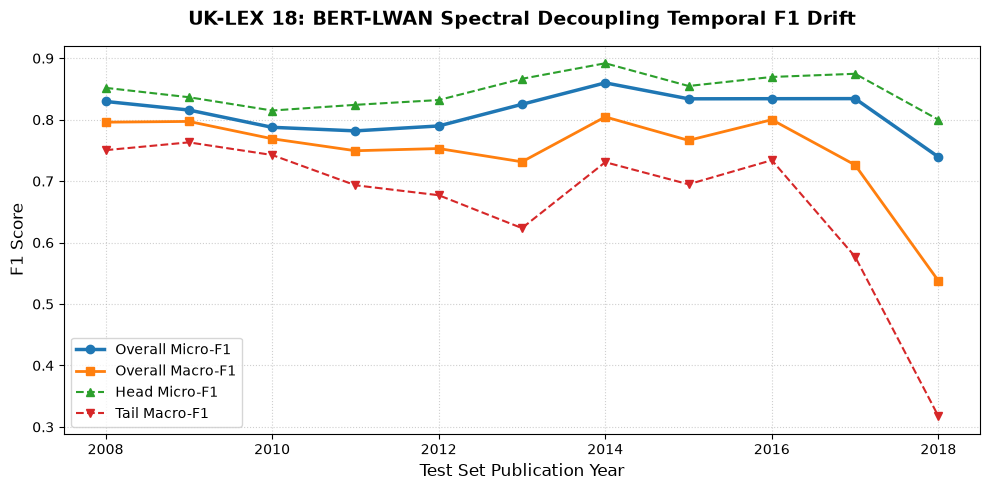

 Saved temporal drift plot to plots/lwan_sd_uk18_drift.png


In [5]:
# Phase 3: LegalBertLWAN on UK-LEX-18 with Spectral Decoupling Loss

# Device selection (Apple MPS / CUDA / CPU)
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))

tokenized_ds, uk_label_to_idx, uk_head_indices, uk_tail_indices = load_uklex18_dataset()
data_collator = get_data_collator()

uk_train_loader = DataLoader(tokenized_ds["train"], batch_size=8,shuffle=True, collate_fn=data_collator)
uk_val_loader   = DataLoader(tokenized_ds["validation"], batch_size=8,shuffle=False, collate_fn=data_collator)
uk_test_loader  = DataLoader(tokenized_ds["test"], batch_size=8,shuffle=False, collate_fn=data_collator)

lwan_sd_uk18_model = LegalBertLWAN(
  model_name="nlpaueb/legal-bert-base-uncased",
  num_labels=len(uk_label_to_idx),
  attention_dim=200,
  dropout=0.1
)
sd_criterion = SpectralDecouplingLoss(lambda_sd=0.01) 
checkpoint_sd_uk18_file ="checkpoints/best_lwan_spectral_decoupling_uk18.pt"

if os.path.exists(checkpoint_sd_uk18_file):
  print(f" Found existing trained checkpoint'{checkpoint_sd_uk18_file}'. Loading weights...")
  lwan_sd_uk18_model.load_state_dict(torch.load(checkpoint_sd_uk18_file,map_location=device))
else:
  print(" Training LegalBertLWAN with Spectral Decoupling Loss(lambda_sd=0.01)...")
  checkpoint_sd_uk18_file = train_model(
  model=lwan_sd_uk18_model,
  train_loader=uk_train_loader,
  val_loader=uk_val_loader,
  head_indices=uk_head_indices,
  tail_indices=uk_tail_indices,
  device=device,
  epochs=3,
  lr=3e-5,
  checkpoint_path=checkpoint_sd_uk18_file,
  accumulation_steps=4,
  criterion=sd_criterion
)

# 5. Chronological Test Set Evaluation
lwan_sd_uk18_model.load_state_dict(torch.load(checkpoint_sd_uk18_file,map_location=device))
lwan_sd_uk18_test_metrics = evaluate_model(lwan_sd_uk18_model,uk_test_loader, device, uk_head_indices, uk_tail_indices)

print("\n" + "="*60)
print("UK-LEX-18 CHRONOLOGICAL TEST RESULTS - SPECTRAL DECOUPLING")
print("="*60)
for k, v in lwan_sd_uk18_test_metrics.items():
  print(f"  • {k:<15}: {v:.4f}")
print("="*60)

save_experiment_results(lwan_sd_uk18_test_metrics,"results/results_lwan_sd_uk18.json")

# Year-by-Year Temporal Drift Evaluation & Plot
lwan_sd_uk18_year_results = evaluate_by_year(
  lwan_sd_uk18_model,
  tokenized_ds["test"],
  device,
  uk_head_indices,
  uk_tail_indices,
  data_collator
)

save_experiment_results(lwan_sd_uk18_year_results,"results/results_lwan_sd_uk18_year_by_year.json")
plot_temporal_drift(lwan_sd_uk18_year_results, title="UK-LEX 18: BERT-LWAN Spectral Decoupling Temporal F1 Drift",
save_path="plots/lwan_sd_uk18_drift.png")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 Training LegalBertLWAN on EUR-LEX-21 with Spectral Decoupling Loss (lambda_sd=0.01)...
Active Device: mps

[12:31:53] Epoch 1/3 | Begin
  [12:32:49] Epoch 1/3 | Batch 50/6875 | Loss: 0.3930
  [12:33:44] Epoch 1/3 | Batch 100/6875 | Loss: 0.2300
  [12:34:39] Epoch 1/3 | Batch 150/6875 | Loss: 0.3376
  [12:35:40] Epoch 1/3 | Batch 200/6875 | Loss: 0.2572
  [12:36:50] Epoch 1/3 | Batch 250/6875 | Loss: 0.1943
  [12:37:58] Epoch 1/3 | Batch 300/6875 | Loss: 0.2616
  [12:39:06] Epoch 1/3 | Batch 350/6875 | Loss: 0.2637
  [12:40:15] Epoch 1/3 | Batch 400/6875 | Loss: 0.2302
  [12:41:24] Epoch 1/3 | Batch 450/6875 | Loss: 0.2637
  [12:42:35] Saved mid-epoch checkpoint at Batch 500/6875
  [12:42:35] Epoch 1/3 | Batch 500/6875 | Loss: 0.2102
  [12:43:45] Epoch 1/3 | Batch 550/6875 | Loss: 0.2348
  [12:44:55] Epoch 1/3 | Batch 600/6875 | Loss: 0.2405
  [12:46:03] Epoch 1/3 | Batch 650/6875 | Loss: 0.2458
  [12:47:10] Epoch 1/3 | Batch 700/6875 | Loss: 0.1878
  [12:48:17] Epoch 1/3 | Batch 750/6

Evaluating:   0%|          | 0/625 [00:00<?, ?it/s]

[15:13:22] --> Epoch 1/3 | Train Loss: 0.2065 | Val Micro-F1: 0.8242 | Val Tail-F1: 0.5519
[15:13:22] Saved checkpoint to checkpoints/best_lwan_spectral_decoupling_eurlex21.pt (Val Micro-F1: 0.8242)

[15:13:22] Epoch 2/3 | Begin
  [15:14:34] Epoch 2/3 | Batch 50/6875 | Loss: 0.1756
  [15:15:46] Epoch 2/3 | Batch 100/6875 | Loss: 0.2428
  [15:16:56] Epoch 2/3 | Batch 150/6875 | Loss: 0.2593
  [15:18:07] Epoch 2/3 | Batch 200/6875 | Loss: 0.1918
  [15:19:18] Epoch 2/3 | Batch 250/6875 | Loss: 0.1768
  [15:20:29] Epoch 2/3 | Batch 300/6875 | Loss: 0.1225
  [15:21:40] Epoch 2/3 | Batch 350/6875 | Loss: 0.2063
  [15:22:52] Epoch 2/3 | Batch 400/6875 | Loss: 0.1872
  [15:24:03] Epoch 2/3 | Batch 450/6875 | Loss: 0.2679
  [15:25:14] Saved mid-epoch checkpoint at Batch 500/6875
  [15:25:14] Epoch 2/3 | Batch 500/6875 | Loss: 0.1901
  [15:26:26] Epoch 2/3 | Batch 550/6875 | Loss: 0.2093
  [15:27:37] Epoch 2/3 | Batch 600/6875 | Loss: 0.1784
  [15:28:48] Epoch 2/3 | Batch 650/6875 | Loss: 0.1928

...

  Evaluated Year 2014: 2264 documents


Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]

  Evaluated Year 2015: 605 documents


Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

  Evaluated Year 2016: 1 documents
 Saved experiment results to results/results_lwan_sd_eurlex21_year_by_year.json


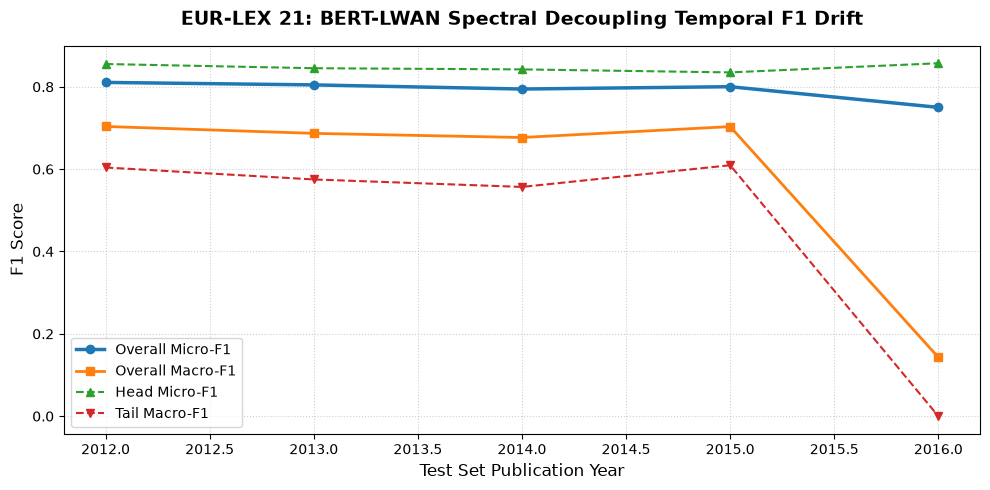

 Saved temporal drift plot to plots/lwan_sd_eurlex21_drift.png


In [6]:
# Phase 3: LegalBertLWAN on EUR-LEX-21 with Spectral Decoupling Loss

device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))

eur_encoded_ds, eur_head_indices, eur_tail_indices = load_eurlex21_dataset()
data_collator = get_data_collator()

eur_train_loader = DataLoader(eur_encoded_ds["train"], batch_size=8, shuffle=True,collate_fn=data_collator)
eur_val_loader   = DataLoader(eur_encoded_ds["validation"], batch_size=8, shuffle=False,collate_fn=data_collator)
eur_test_loader  = DataLoader(eur_encoded_ds["test"], batch_size=8, shuffle=False,collate_fn=data_collator)

# Initialize Model and Spectral Decoupling Loss (21 labels)
lwan_sd_eur21_model = LegalBertLWAN(
  model_name="nlpaueb/legal-bert-base-uncased",
  num_labels=21,
  attention_dim=200,
  dropout=0.1
)

sd_criterion = SpectralDecouplingLoss(lambda_sd=0.01)
checkpoint_sd_eur21_file = "checkpoints/best_lwan_spectral_decoupling_eurlex21.pt"

if os.path.exists(checkpoint_sd_eur21_file):
  print(f" Found existing trained checkpoint '{checkpoint_sd_eur21_file}'. Loading weights...")
  lwan_sd_eur21_model.load_state_dict(torch.load(checkpoint_sd_eur21_file, map_location=device)) 
else:
  print(" Training LegalBertLWAN on EUR-LEX-21 with Spectral Decoupling Loss (lambda_sd=0.01)...")
  checkpoint_sd_eur21_file = train_model(
  model=lwan_sd_eur21_model,
  train_loader=eur_train_loader,
  val_loader=eur_val_loader,
  head_indices=eur_head_indices,
  tail_indices=eur_tail_indices,
  device=device,
  epochs=3,
  lr=3e-5,
  checkpoint_path=checkpoint_sd_eur21_file,
  accumulation_steps=4,
  criterion=sd_criterion
)

# Chronological Test Set Evaluation
lwan_sd_eur21_model.load_state_dict(torch.load(checkpoint_sd_eur21_file, map_location=device))
lwan_sd_eur21_test_metrics = evaluate_model(lwan_sd_eur21_model, eur_test_loader, device, eur_head_indices,eur_tail_indices)

print("\n" + "="*60)
print("EUR-LEX-21 CHRONOLOGICAL TEST RESULTS - SPECTRAL DECOUPLING")
print("="*60)
for k, v in lwan_sd_eur21_test_metrics.items():
  print(f"  • {k:<15}: {v:.4f}")
print("="*60)

save_experiment_results(lwan_sd_eur21_test_metrics, "results/results_lwan_sd_eurlex21.json")

# Year-by-Year Temporal Drift Evaluation & Plot
lwan_sd_eur21_year_results = evaluate_by_year(
  lwan_sd_eur21_model,
  eur_encoded_ds["test"],
  device,
  eur_head_indices,
  eur_tail_indices,
  data_collator
)
save_experiment_results(lwan_sd_eur21_year_results, "results/results_lwan_sd_eurlex21_year_by_year.json")
plot_temporal_drift(lwan_sd_eur21_year_results, title="EUR-LEX 21: BERT-LWAN Spectral Decoupling Temporal F1 Drift", save_path="plots/lwan_sd_eurlex21_drift.png")

# Phase 4: LLM Decoder 
### Llama-3 Zero-Shot and Few-Shot Evaluation

In [ ]:
### Google Colab Setup & HuggingFace Authentication
# If running this notebook in Google Colab, run the cell below to install required packages and log in to Hugging Face for Llama-3 access.

import sys

if 'google.colab' in sys.modules:
    print("⚡ Google Colab environment detected. Installing required GPU packages...")
    !pip install -q transformers bitsandbytes accelerate datasets scipy huggingface_hub
    
    from huggingface_hub import login
    print("Authenticate with your HuggingFace Token (Meta-Llama-3-8B access):")
    login()
else:
    print("Running in local environment.")

#### 4.1. Prompt Engineering

In [5]:
# Define Candidate Label Lists matching exact dataset vocabulary
uk18_candidate_labels = sorted(list(uk_label_to_idx.keys()))

# EUR-LEX-21 Level 1 EuroVoc category names
eur21_candidate_labels = [
    "POLITICS", "INTERNATIONAL RELATIONS", "EUROPEAN UNION", "LAW",
    "ECONOMICS", "TRADE", "FINANCE", "SOCIAL QUESTIONS", "EDUCATION AND COMMUNICATIONS",
    "SCIENCE", "EMPLOYMENT AND WORKING CONDITIONS", "TRANSPORT", "ENVIRONMENT", "AGRICULTURE, FORESTRY AND FISHERIES", 
    "AGRI-FOODSTUFFS", "PRODUCTION,TECHNOLOGY AND RESEARCH", "ENERGY", "INDUSTRY", "GEOGRAPHY", 
    "INTERNATIONAL ORGANISATIONS","BUSINESS AND COMPETITION"
]

# Initialize Llama Prompt Builders
uk18_prompt_builder = LlamaPromptBuilder(
    candidate_labels=uk18_candidate_labels,
    domain_name="UK Statutory Legislation (UK-LEX-18)"
)

eur21_prompt_builder = LlamaPromptBuilder(
    candidate_labels=eur21_candidate_labels,
    domain_name="EUR-LEX EuroVoc (EUR-LEX-21)"
)

# Access unformatted raw datasets to retrieve full original text and title
uk_test_raw = uklex_tokenized['test'].with_format(None) if hasattr(uklex_tokenized['test'], 'with_format') else uklex_tokenized['test']
eur_test_raw = encoded_ds['test'].with_format(None) if hasattr(encoded_ds['test'], 'with_format') else encoded_ds['test']

# Decode sample document from UK-LEX-18 test set
sample_uk_title, sample_uk_text, _ = extract_sample_meta(uk_test_raw[0], max_chars=3500)
sample_uk_prompt = uk18_prompt_builder.build_zero_shot_prompt(document_text=sample_uk_text, document_title=sample_uk_title)

print("--- Sample UK-LEX-18 Zero-Shot Prompt Preview ---")
print(sample_uk_prompt[:600] + "\n...")

# Decode sample document from EUR-LEX-21 test set
sample_eur_title, sample_eur_text, _ = extract_sample_meta(eur_test_raw[0], max_chars=3500)
sample_eur_prompt = eur21_prompt_builder.build_zero_shot_prompt(document_text=sample_eur_text, document_title=sample_eur_title)

print("--- Sample EUR-LEX-21 Zero-Shot Prompt Preview ---")
print(sample_eur_prompt[:600] + "\n...")

# Batch Prompt Generation for both Chronological Test Sets
uk18_test_prompts = [
    uk18_prompt_builder.build_zero_shot_prompt(
        document_text=extract_sample_meta(doc, max_chars=3500)[1],
        document_title=extract_sample_meta(doc, max_chars=3500)[0]
    )
    for doc in tqdm(uk_test_raw, desc="Generating UK-LEX-18 Zero-Shot Prompts")
]

eur21_test_prompts = [
    eur21_prompt_builder.build_zero_shot_prompt(
        document_text=extract_sample_meta(doc, max_chars=3500)[1],
        document_title=extract_sample_meta(doc, max_chars=3500)[0]
    )
    for doc in tqdm(eur_test_raw, desc="Generating EUR-LEX-21 Zero-Shot Prompts")
]

print(f"Generated {len(uk18_test_prompts):,} zero-shot prompts for UK-LEX-18 Test Set (2008-2018)")
print(f"Generated {len(eur21_test_prompts):,} zero-shot prompts for EUR-LEX-21 Test Set (2012-2016)")


--- Sample UK-LEX-18 Zero-Shot Prompt Preview ---
You are an expert legal text classifier analyzing UK Statutory Legislation (UK-LEX-18) statutory legislation.

Your task is to assign all relevant legal subject categories to the document below.

Candidate Legal Categories:
 - AGRICULTURE & FOOD
 - CHILDREN
 - CRIMINAL LAW
 - EDUCATION
 - ENVIRONMENT
 - EU
 - FINANCE
 - HEALTH CARE
 - HOUSING
 - IMMIGRATION & CITIZENSHIP
 - LOCAL GOVERNMENT
 - PLANNING & DEVELOPMENT
 - POLITICS
 - PUBLIC ORDER
 - SOCIAL SECURITY
 - TAXATION
 - TELECOMMUNICATIONS
 - TRANSPORTATION

Document Title: N/A
Document Text:
"""
citation, commencement and interpretation
...
--- Sample EUR-LEX-21 Zero-Shot Prompt Preview ---
You are an expert legal text classifier analyzing EUR-LEX EuroVoc (EUR-LEX-21) statutory legislation.

Your task is to assign all relevant legal subject categories to the document below.

Candidate Legal Categories:
 - AGRI-FOODSTUFFS
 - AGRICULTURE, FORESTRY AND FISHERIES
 - BUSINESS AND COMP

#### 4.2. Llama-3-8B 4-Bit Model Initialization

In [6]:
# Load Meta-Llama-3-8B with 4-bit NF4 `bitsandbytes` quantization for Cloud GPU / Colab Pro, with local fallback.

MODEL_ID = "meta-llama/Meta-Llama-3-8B-Instruct"

# 4-bit NormalFloat (NF4) Quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

# Verify GPU availability for 4-bit bitsandbytes inference
if torch.cuda.is_available():
    print(f"Loading {MODEL_ID} in 4-bit NF4 mode on GPU ({torch.cuda.get_device_name(0)})...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        
    llama_model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map="auto"
    )
    print("✓ Model loaded successfully into VRAM.")
else:
    print("No CUDA GPU detected locally. This cell is configured for Google Colab Pro / Cloud GPU execution.")
    print("If testing locally on Mac, ensure Ollama server is running with 'ollama run llama3:8b'.")


No CUDA GPU detected locally. This cell is configured for Google Colab Pro / Cloud GPU execution.
If testing locally on Mac, ensure Ollama server is running with 'ollama run llama3:8b'.


#### 4.3. Llama-3 Zero-Shot Batch Inference and Temporal F1 Metrics

In [ ]:
# 4.3. Zero-Shot Evaluation, Regex JSON Parsing & Temporal F1 Metrics

# Run Evaluation on UK-LEX-18 (Full test set evaluation with GPU batching)
uk_llama3_metrics, uk_llama3_preds = evaluate_llama3_zero_shot(
    prompts=uk18_test_prompts,
    dataset_split=uklex_tokenized['test'],
    candidate_labels=uk18_candidate_labels,
    head_indices=uk_head_indices,
    tail_indices=uk_tail_indices,
    dataset_name="UK-LEX-18",
    max_samples=None,
    save_every=100,
    batch_size=32,
    max_new_tokens=50,
    llama_model=llama_model,
    tokenizer=tokenizer
)
save_experiment_results(uk_llama3_metrics, "results/results_llama3_zero_shot_uk18.json")

In [ ]:
# Year-by-Year Temporal Drift Breakdown for UK-LEX-18
uk_llama3_yearly = evaluate_predictions_by_year(
    uk_llama3_preds, uklex_tokenized['test'], uk_head_indices, uk_tail_indices
)
save_experiment_results(uk_llama3_yearly, "results/results_llama3_zero_shot_uk18_year_by_year.json")
plot_temporal_drift(uk_llama3_yearly, title="UK-LEX-18: Llama-3-8B Zero-Shot Temporal F1 Drift", save_path="plots/llama3_uk18_temporal_drift.png")

In [ ]:
# Run Evaluation on EUR-LEX-21 (Full test set evaluation with GPU batching)
eur_llama3_metrics, eur_llama3_preds = evaluate_llama3_zero_shot(
    prompts=eur21_test_prompts,
    dataset_split=encoded_ds['test'],
    candidate_labels=eur21_candidate_labels,
    head_indices=eur_head_indices,
    tail_indices=eur_tail_indices,
    dataset_name="EUR-LEX-21",
    max_samples=None,
    save_every=100,
    batch_size=32,
    max_new_tokens=50,
    llama_model=llama_model,
    tokenizer=tokenizer
)
save_experiment_results(eur_llama3_metrics, "results/results_llama3_zero_shot_eurlex21.json")

In [ ]:
# Year-by-Year Temporal Drift Breakdown for EUR-LEX-21
eur_llama3_yearly = evaluate_predictions_by_year(
    eur_llama3_preds, encoded_ds['test'], eur_head_indices, eur_tail_indices
)
save_experiment_results(eur_llama3_yearly, "results/results_llama3_zero_shot_eurlex21_year_by_year.json")
plot_temporal_drift(eur_llama3_yearly, title="EUR-LEX-21: Llama-3-8B Zero-Shot Temporal F1 Drift", save_path="plots/llama3_eur21_temporal_drift.png")

# Phase 4B: Advanced In-Context Few-Shot Learning and Chat Templates
Evaluates Llama-3-8B-Instruct using 3-shot in-context legal exemplars, official Llama-3 <|start_header_id|> chat markup formatting, expanded token budgets (max_new_tokens=100), and 3,500-character context windows to maximize multi-label precision and recall under temporal drift.


In [ ]:
# Advanced Few-Shot Evaluation on UK-LEX-18

uk_fewshot_metrics, uk_fewshot_preds = evaluate_llama3_few_shot(
    test_dataset=uklex_tokenized['test'],
    train_dataset=uklex_tokenized['train'],
    candidate_labels=uk18_candidate_labels,
    head_indices=uk_head_indices,
    tail_indices=uk_tail_indices,
    dataset_name="UK-LEX-18",
    n_shots=3,
    batch_size=8,
    max_new_tokens=100,
    llama_model=llama_model,
    tokenizer=tokenizer
)
save_experiment_results(uk_fewshot_metrics, "results/results_llama3_fewshot_uk18.json")

In [ ]:
# Year-by-Year Temporal Drift Breakdown for UK-LEX-18 Few-Shot
uk_fewshot_yearly = evaluate_predictions_by_year(
    uk_fewshot_preds, uklex_tokenized['test'], uk_head_indices, uk_tail_indices
)
save_experiment_results(uk_fewshot_yearly, "results/results_llama3_fewshot_uk18_year_by_year.json")
plot_temporal_drift(uk_fewshot_yearly, title="UK-LEX-18: Tier 4 Llama-3-8B Few-Shot Temporal Drift", save_path="plots/llama3_uk18_fewshot_temporal_drift.png")

In [ ]:
# Advanced Few-Shot Evaluation on EUR-LEX-21
eur_fewshot_metrics, eur_fewshot_preds = evaluate_llama3_few_shot(
    test_dataset=encoded_ds['test'],
    train_dataset=encoded_ds['train'],
    candidate_labels=eur21_candidate_labels,
    head_indices=eur_head_indices,
    tail_indices=eur_tail_indices,
    dataset_name="EUR-LEX-21",
    n_shots=3,
    batch_size=32,
    max_new_tokens=100,
    llama_model=llama_model,
    tokenizer=tokenizer
)
save_experiment_results(eur_fewshot_metrics, "results/results_llama3_fewshot_eurlex21.json")

In [ ]:
# Year-by-Year Temporal Drift Breakdown for EUR-LEX-21 Few-Shot
eur_fewshot_yearly = evaluate_predictions_by_year(
    eur_fewshot_preds, encoded_ds['test'], eur_head_indices, eur_tail_indices
)
save_experiment_results(eur_fewshot_yearly, "results/results_llama3_fewshot_eurlex21_year_by_year.json")
plot_temporal_drift(eur_fewshot_yearly, title="EUR-LEX-21: Tier 4 Llama-3-8B Few-Shot Temporal Drift", save_path="plots/llama3_eur21_fewshot_temporal_drift.png")
